# Empirical Study: Semantic Similarity as Correctness Proxy
**Project:** Semantic Similarity Measurement in Latent Space for LLM Prediction Evaluation  
**Model:** Qwen3-4B (thinking / no_thinking ablation)  
**Datasets:** SciQ, SimpleQA (short-form) · NQ, TruthfulQA (long-form)

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, auc as sklearn_auc

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)

RESULTS_DIR = '../results'
FIGURES_DIR = '../results/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

DATASETS     = ['sciq', 'simpleqa', 'natural_questions', 'truthfulqa']
MODES        = ['no_thinking', 'thinking']
EMB_MODELS   = ['bge-base', 'minilm', 'e5-base']
SHORT_FORM   = ['sciq', 'simpleqa']
LONG_FORM    = ['natural_questions', 'truthfulqa']

PALETTE = {'correct': '#2196F3', 'incorrect': '#F44336',
           'Correct': '#2196F3', 'Incorrect': '#F44336'}
MODE_COLORS = {'no_thinking': '#4CAF50', 'thinking': '#FF9800'}
print('Imports OK')

Imports OK


## 1. Load Results

In [2]:
# Load all per-sample similarity CSVs into one DataFrame
frames = []
for ds in DATASETS:
    for mode in MODES:
        for emb in EMB_MODELS:
            path = os.path.join(RESULTS_DIR, f'{ds}_{mode}_{emb}_similarity.csv')
            if os.path.exists(path):
                df = pd.read_csv(path)
                df['emb_model'] = emb
                frames.append(df)

all_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f'Total samples loaded: {len(all_df)}')
all_df.head(3)

Total samples loaded: 12702


,id,question,prediction,ground_truth,dataset,task_type,thinking_mode,is_correct,correctness_score,similarity,emb_model
0,sciq_0,"When resources are limited, populations exhibi...",Logistic growth.,logistic growth,sciq,short_form,no_thinking,1,1.0,0.968786,bge-base
1,sciq_1,The sun gives off energy in tiny packets calle...,Photons.,photons,sciq,short_form,no_thinking,1,1.0,0.933303,bge-base
2,sciq_2,The three parts of the human small intestine i...,Ileum,ileum,sciq,short_form,no_thinking,1,1.0,1.000000,bge-base


In [3]:
# Load AUC summary
auc_path = os.path.join(RESULTS_DIR, 'summary_auc.csv')
auc_df = pd.read_csv(auc_path) if os.path.exists(auc_path) else pd.DataFrame()

# Load group stats summary
stats_path = os.path.join(RESULTS_DIR, 'summary_stats.csv')
stats_df = pd.read_csv(stats_path) if os.path.exists(stats_path) else pd.DataFrame()

# Load failure summary
fail_path = os.path.join(RESULTS_DIR, 'failure_summary.csv')
fail_df = pd.read_csv(fail_path) if os.path.exists(fail_path) else pd.DataFrame()

print('AUC summary:')
display(auc_df)

AUC summary:


,dataset,thinking_mode,emb_model,auc,n_pos,n_neg,threshold,youden_j,f1_at_threshold
0,sciq,no_thinking,bge-base,0.940188,261,239,0.842412,0.735488,0.873563
1,sciq,no_thinking,minilm,0.953783,261,239,0.857379,0.760993,0.875764
2,sciq,no_thinking,e5-base,0.933471,261,239,0.941409,0.726815,0.862823
3,sciq,thinking,bge-base,0.902272,304,196,0.841813,0.698912,0.873524
4,sciq,thinking,minilm,0.934043,304,196,0.859353,0.774302,0.891228
5,sciq,thinking,e5-base,0.889819,304,196,0.943113,0.708647,0.865620
6,simpleqa,no_thinking,bge-base,0.975723,16,484,0.778273,0.912707,0.697674
7,simpleqa,no_thinking,minilm,0.932980,16,484,0.809737,0.835744,0.571429
8,simpleqa,no_thinking,e5-base,0.930527,16,484,0.940442,0.852273,0.682927
9,simpleqa,thinking,bge-base,0.934143,16,484,0.872106,0.875000,0.933333


## 2. Similarity Score Distributions
Correct vs Incorrect predictions per dataset and embedding model.

Saved → ../results/figures/distributions_no_thinking_bge-base.pdf


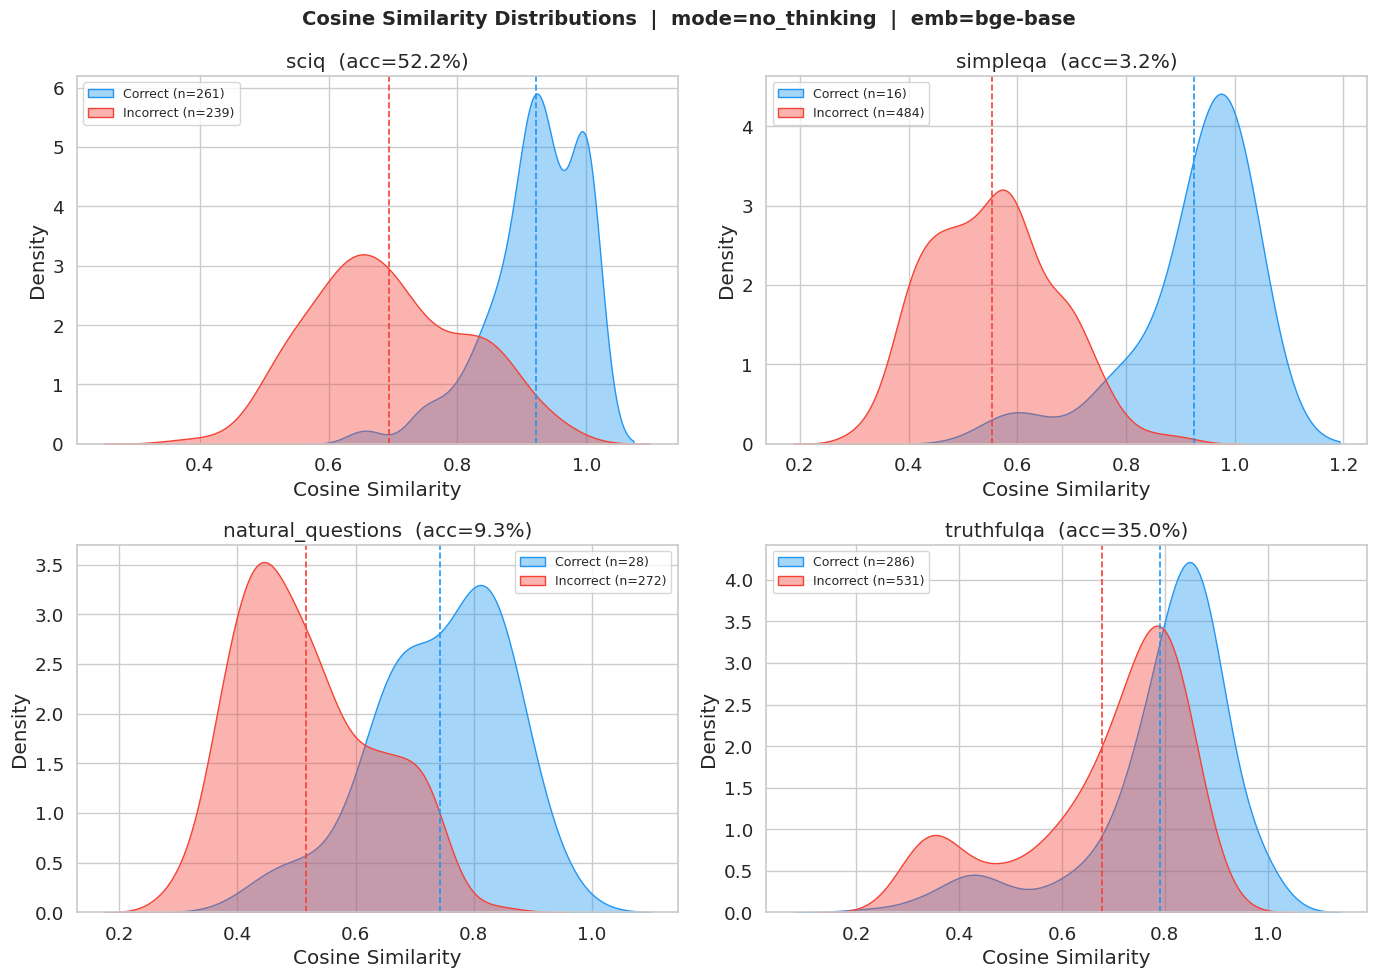

In [4]:
def plot_similarity_distributions(df, mode='no_thinking', emb='bge-base', save=True):
    sub = df[(df['thinking_mode'] == mode) & (df['emb_model'] == emb)]
    if sub.empty:
        print(f'No data for mode={mode}, emb={emb}')
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f'Cosine Similarity Distributions  |  mode={mode}  |  emb={emb}',
        fontsize=14, fontweight='bold'
    )

    for ax, ds in zip(axes.flat, DATASETS):
        dds = sub[sub['dataset'] == ds]
        if dds.empty:
            ax.set_visible(False)
            continue
        for label, color in [(1, PALETTE['correct']), (0, PALETTE['incorrect'])]:
            vals = dds[dds['is_correct'] == label]['similarity']
            name = 'Correct' if label == 1 else 'Incorrect'
            sns.kdeplot(vals, ax=ax, fill=True, alpha=0.4, color=color, label=f'{name} (n={len(vals)})')
            ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.2)
        acc = dds['is_correct'].mean() * 100
        ax.set_title(f'{ds}  (acc={acc:.1f}%)')
        ax.set_xlabel('Cosine Similarity')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)

    plt.tight_layout()
    if save:
        path = os.path.join(FIGURES_DIR, f'distributions_{mode}_{emb}.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

plot_similarity_distributions(all_df, mode='no_thinking', emb='bge-base')

## 3. ROC Curves

Saved → ../results/figures/roc_no_thinking.pdf


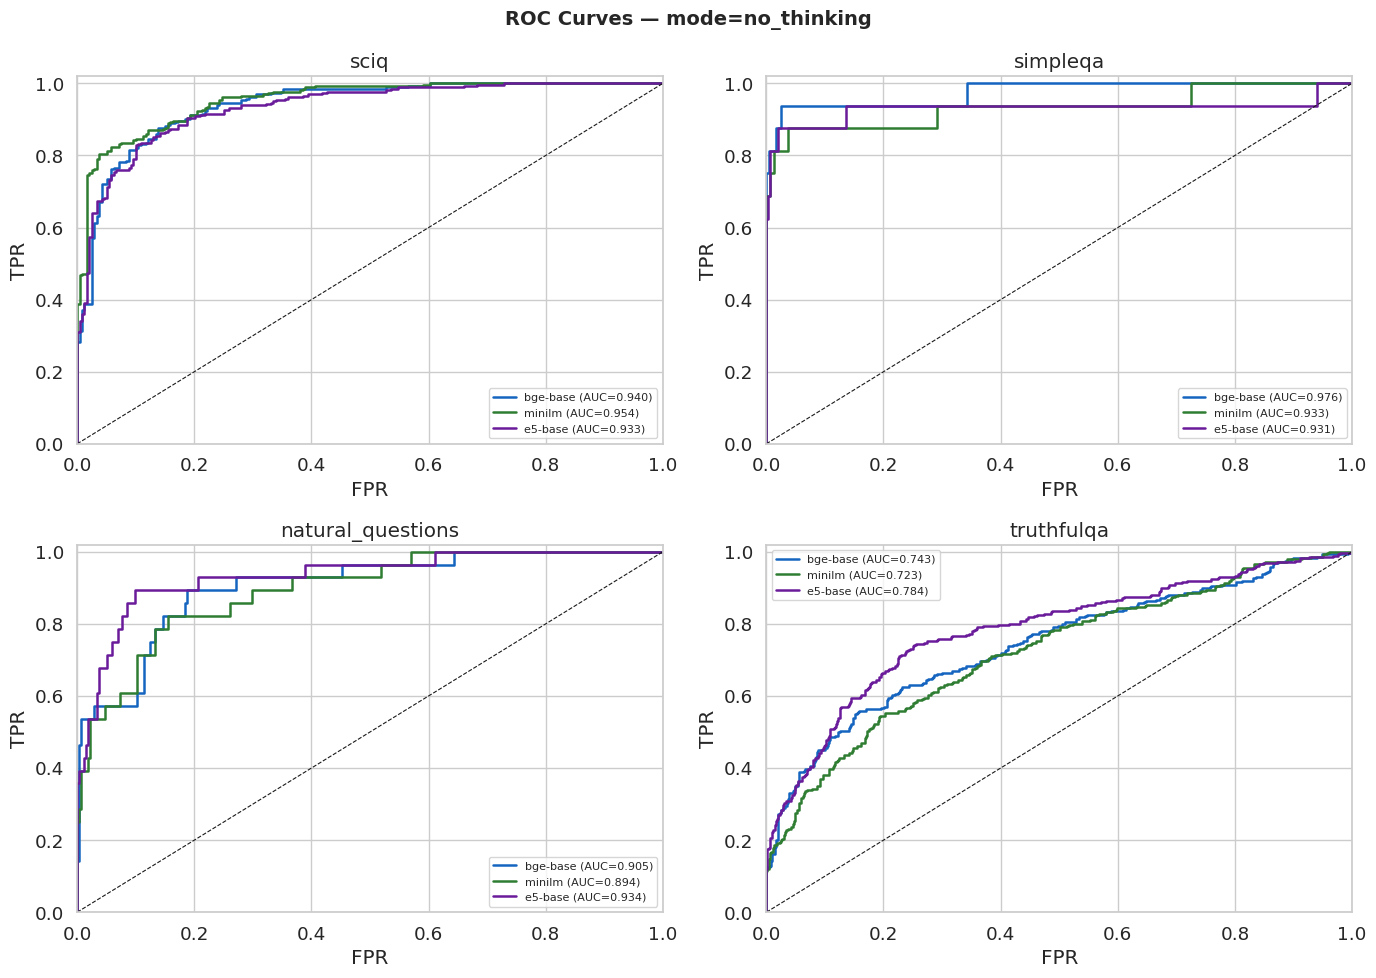

Saved → ../results/figures/roc_thinking.pdf


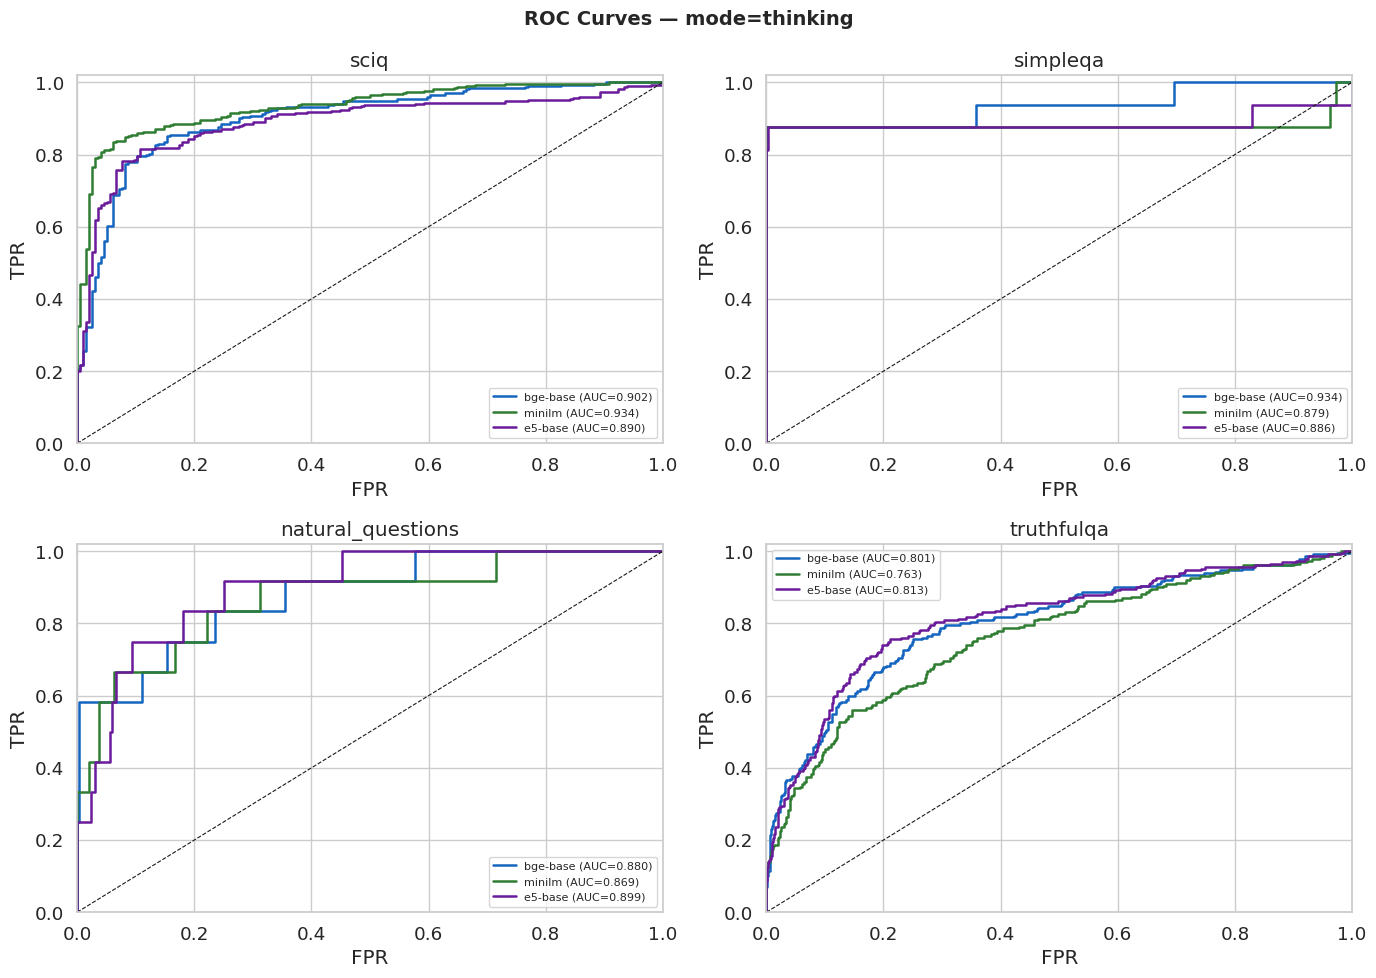

In [5]:
def plot_roc_curves(df, mode='no_thinking', save=True):
    sub = df[df['thinking_mode'] == mode]
    if sub.empty:
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'ROC Curves — mode={mode}', fontsize=14, fontweight='bold')
    emb_colors = {'bge-base': '#1565C0', 'minilm': '#2E7D32', 'e5-base': '#6A1B9A'}

    for ax, ds in zip(axes.flat, DATASETS):
        dds = sub[sub['dataset'] == ds]
        if dds.empty or dds['is_correct'].nunique() < 2:
            ax.set_visible(False)
            continue
        for emb, color in emb_colors.items():
            emb_data = dds[dds['emb_model'] == emb]
            if emb_data.empty:
                continue
            fpr, tpr, _ = roc_curve(emb_data['is_correct'], emb_data['similarity'])
            roc_auc = sklearn_auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, linewidth=1.8,
                    label=f'{emb} (AUC={roc_auc:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
        ax.set_title(ds)
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(fontsize=8)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.02])

    plt.tight_layout()
    if save:
        path = os.path.join(FIGURES_DIR, f'roc_{mode}.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

for m in MODES:
    plot_roc_curves(all_df, mode=m)

## 4. AUC Heatmap (Dataset × Embedding Model)

Saved → ../results/figures/auc_heatmap_no_thinking.pdf


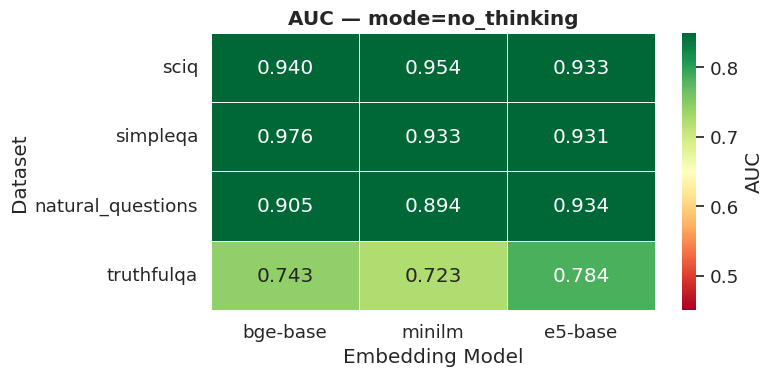

Saved → ../results/figures/auc_heatmap_thinking.pdf


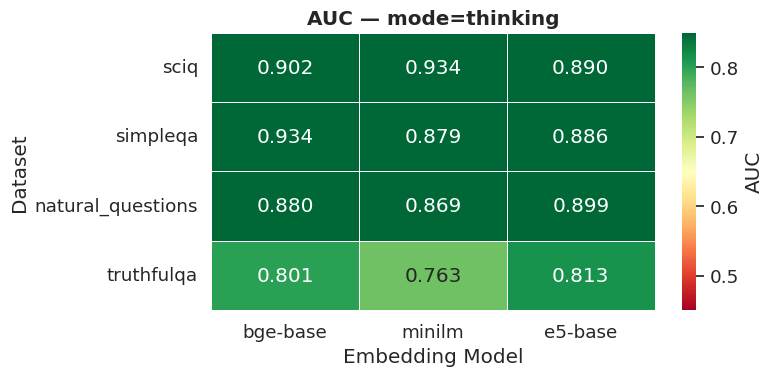

In [6]:
def plot_auc_heatmap(auc_df, mode='no_thinking', save=True):
    sub = auc_df[auc_df['thinking_mode'] == mode]
    if sub.empty:
        return
    pivot = sub.pivot(index='dataset', columns='emb_model', values='auc')
    # Reorder
    pivot = pivot.reindex(index=[d for d in DATASETS if d in pivot.index],
                          columns=[e for e in EMB_MODELS if e in pivot.columns])

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(
        pivot, annot=True, fmt='.3f', cmap='RdYlGn',
        vmin=0.45, vmax=0.85, linewidths=0.5, ax=ax,
        cbar_kws={'label': 'AUC'}
    )
    ax.set_title(f'AUC — mode={mode}', fontweight='bold')
    ax.set_xlabel('Embedding Model')
    ax.set_ylabel('Dataset')
    plt.tight_layout()
    if save:
        path = os.path.join(FIGURES_DIR, f'auc_heatmap_{mode}.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

for m in MODES:
    plot_auc_heatmap(auc_df, mode=m)

## 5. Short-form vs Long-form Comparison

Saved → ../results/figures/short_vs_long_bge-base.pdf


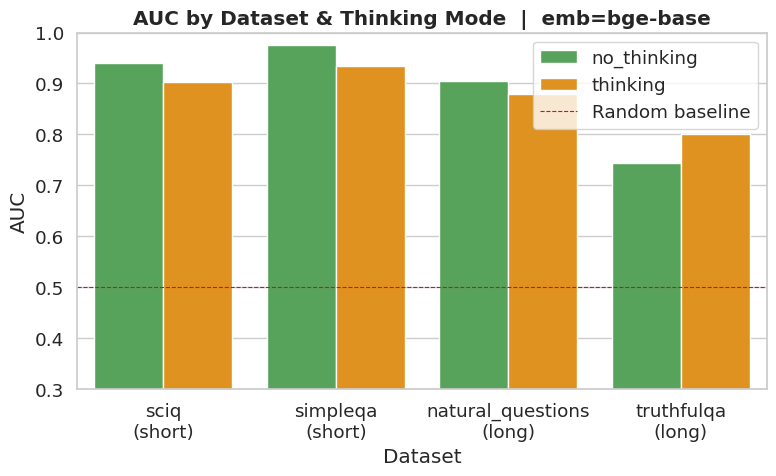

In [7]:
def plot_short_vs_long(auc_df, emb='bge-base', save=True):
    sub = auc_df[auc_df['emb_model'] == emb].copy()
    sub['form'] = sub['dataset'].apply(
        lambda d: 'short_form' if d in SHORT_FORM else 'long_form'
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=sub, x='dataset', y='auc', hue='thinking_mode',
        palette=MODE_COLORS, ax=ax, capsize=0.05
    )
    ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Random baseline')
    ax.set_title(f'AUC by Dataset & Thinking Mode  |  emb={emb}', fontweight='bold')
    ax.set_xlabel('Dataset')
    ax.set_ylabel('AUC')
    ax.set_ylim([0.3, 1.0])
    ax.legend()

    # Add form labels on x-axis ticks
    tick_labels = [
        f'{d}\n({"short" if d in SHORT_FORM else "long"})'
        for d in sub['dataset'].unique()
    ]
    ax.set_xticklabels(tick_labels)
    plt.tight_layout()
    if save:
        path = os.path.join(FIGURES_DIR, f'short_vs_long_{emb}.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

plot_short_vs_long(auc_df)

## 6. Thinking vs No-thinking Ablation

Saved → ../results/figures/thinking_ablation_bge-base.pdf


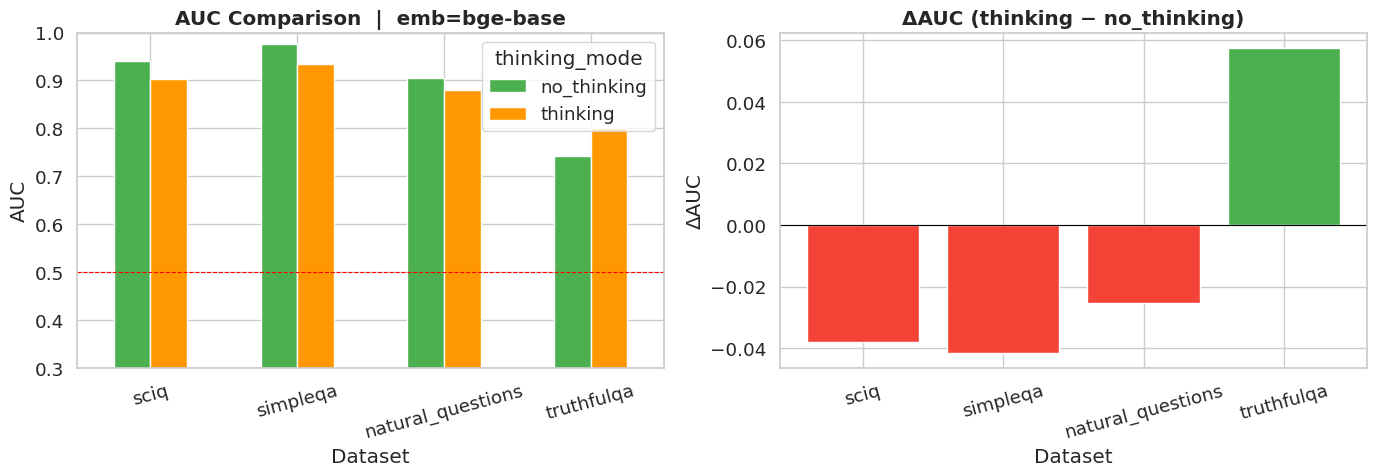

In [8]:
def plot_thinking_ablation(auc_df, emb='bge-base', save=True):
    sub = auc_df[auc_df['emb_model'] == emb]
    if sub.empty:
        return

    pivot = sub.pivot(index='dataset', columns='thinking_mode', values='auc')
    pivot = pivot.reindex([d for d in DATASETS if d in pivot.index])

    if 'thinking' not in pivot.columns or 'no_thinking' not in pivot.columns:
        print('Both thinking modes required for ablation plot')
        return

    pivot['delta'] = pivot['thinking'] - pivot['no_thinking']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Side-by-side bar
    pivot[['no_thinking', 'thinking']].plot(
        kind='bar', ax=axes[0],
        color=[MODE_COLORS['no_thinking'], MODE_COLORS['thinking']],
        edgecolor='white'
    )
    axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8)
    axes[0].set_title(f'AUC Comparison  |  emb={emb}', fontweight='bold')
    axes[0].set_xlabel('Dataset')
    axes[0].set_ylabel('AUC')
    axes[0].set_ylim([0.3, 1.0])
    axes[0].tick_params(axis='x', rotation=15)

    # Delta plot
    colors = ['#4CAF50' if v > 0 else '#F44336' for v in pivot['delta']]
    axes[1].bar(pivot.index, pivot['delta'], color=colors, edgecolor='white')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('ΔAUC (thinking − no_thinking)', fontweight='bold')
    axes[1].set_xlabel('Dataset')
    axes[1].set_ylabel('ΔAUC')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    if save:
        path = os.path.join(FIGURES_DIR, f'thinking_ablation_{emb}.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

plot_thinking_ablation(auc_df)

## 7. Box Plots — Similarity by Correct/Incorrect

Saved → ../results/figures/boxplot_no_thinking_bge-base.pdf


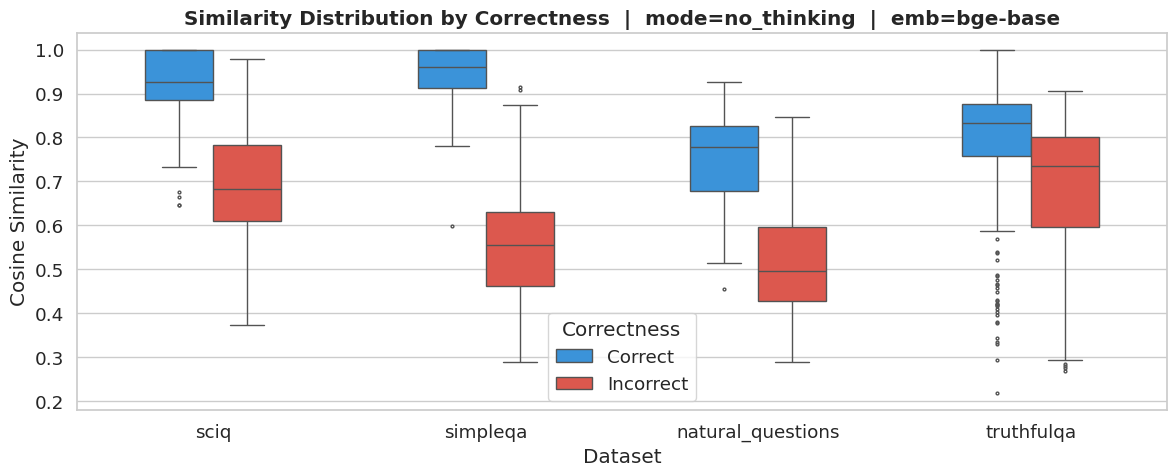

In [9]:
def plot_boxplots(df, mode='no_thinking', emb='bge-base', save=True):
    sub = df[(df['thinking_mode'] == mode) & (df['emb_model'] == emb)].copy()
    sub['Correctness'] = sub['is_correct'].map({1: 'Correct', 0: 'Incorrect'})

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        data=sub, x='dataset', y='similarity', hue='Correctness',
        palette=PALETTE, ax=ax, width=0.5, fliersize=2
    )
    ax.set_title(f'Similarity Distribution by Correctness  |  mode={mode}  |  emb={emb}',
                 fontweight='bold')
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Cosine Similarity')
    plt.tight_layout()
    if save:
        path = os.path.join(FIGURES_DIR, f'boxplot_{mode}_{emb}.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

plot_boxplots(all_df)

## 8. Failure Case Analysis

Saved → ../results/figures/failure_causes_no_thinking.pdf


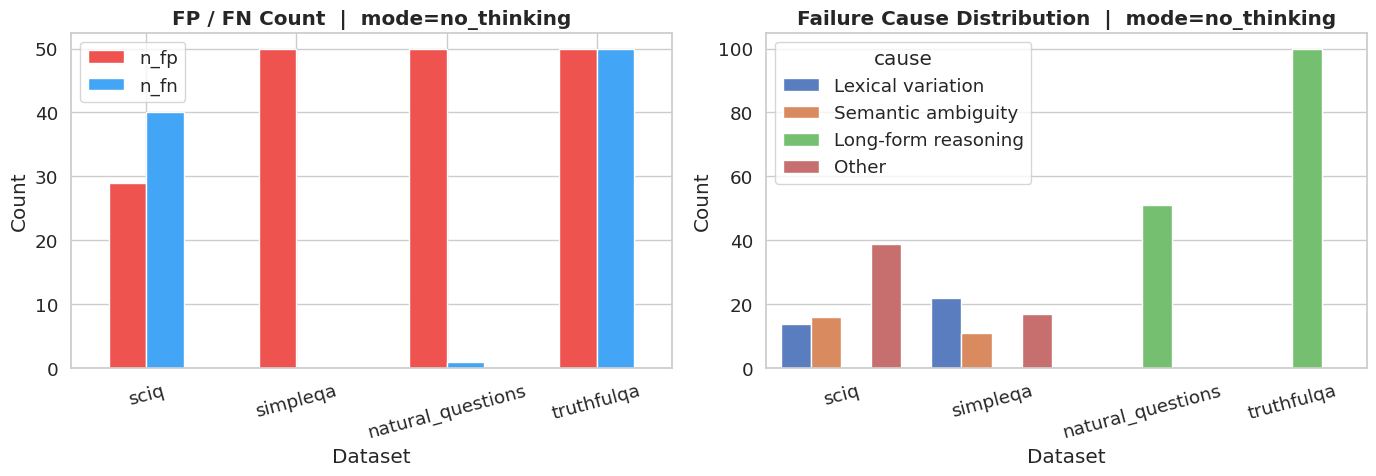

Saved → ../results/figures/failure_causes_thinking.pdf


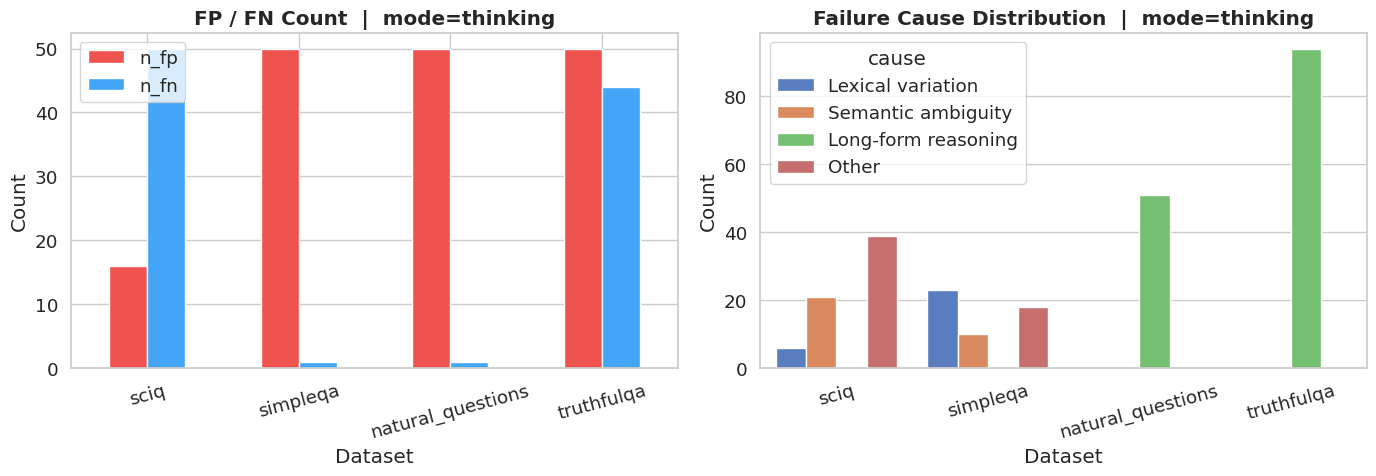

In [10]:
def plot_failure_causes(fail_df, mode='no_thinking', save=True):
    sub = fail_df[fail_df['thinking_mode'] == mode]
    if sub.empty:
        return

    cause_cols = ['n_lexical_variation', 'n_semantic_ambiguity',
                  'n_long_form_reasoning', 'n_other']
    cause_labels = ['Lexical variation', 'Semantic ambiguity',
                    'Long-form reasoning', 'Other']

    melted = sub.melt(
        id_vars=['dataset'], value_vars=cause_cols,
        var_name='cause', value_name='count'
    )
    melted['cause'] = melted['cause'].map(dict(zip(cause_cols, cause_labels)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # FP / FN breakdown per dataset
    sub[['dataset', 'n_fp', 'n_fn']].set_index('dataset').plot(
        kind='bar', ax=axes[0], color=['#EF5350', '#42A5F5'], edgecolor='white'
    )
    axes[0].set_title(f'FP / FN Count  |  mode={mode}', fontweight='bold')
    axes[0].set_xlabel('Dataset')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=15)

    # Failure cause stacked bar
    sns.barplot(data=melted, x='dataset', y='count', hue='cause', ax=axes[1])
    axes[1].set_title(f'Failure Cause Distribution  |  mode={mode}', fontweight='bold')
    axes[1].set_xlabel('Dataset')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    if save:
        path = os.path.join(FIGURES_DIR, f'failure_causes_{mode}.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

for m in MODES:
    plot_failure_causes(fail_df, mode=m)

## 9. Correlation: Similarity Score vs Answer Length

Saved → ../results/figures/sim_vs_length_no_thinking_bge-base.pdf


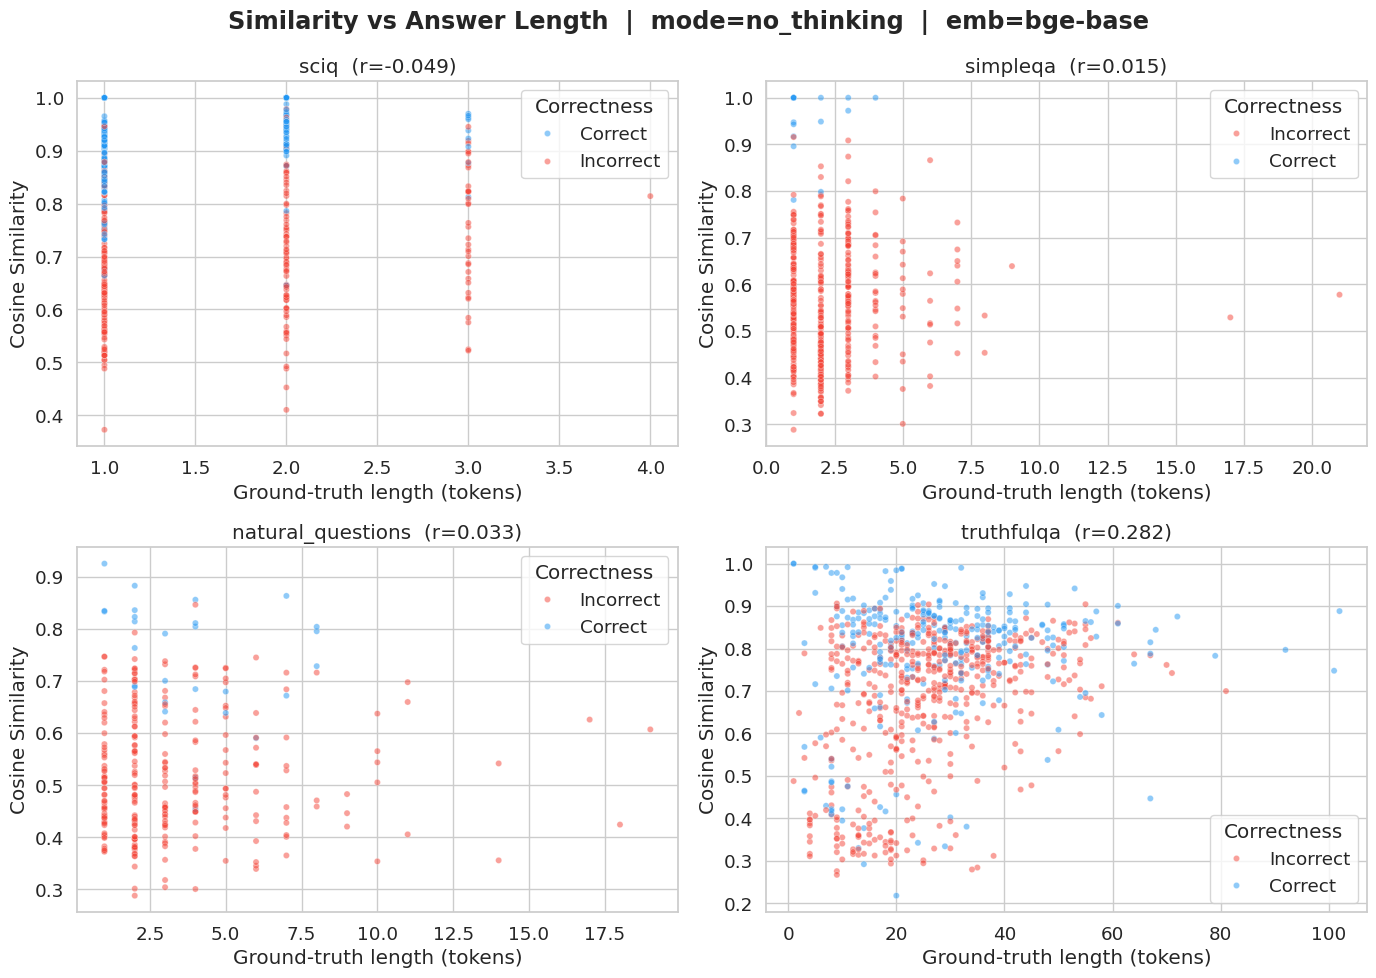

In [11]:
def plot_sim_vs_length(df, mode='no_thinking', emb='bge-base', save=True):
    sub = df[(df['thinking_mode'] == mode) & (df['emb_model'] == emb)].copy()
    sub['gt_len'] = sub['ground_truth'].astype(str).apply(lambda x: len(x.split()))
    sub['Correctness'] = sub['is_correct'].map({1: 'Correct', 0: 'Incorrect'})

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f'Similarity vs Answer Length  |  mode={mode}  |  emb={emb}',
        fontweight='bold'
    )

    for ax, ds in zip(axes.flat, DATASETS):
        dds = sub[sub['dataset'] == ds]
        if dds.empty:
            ax.set_visible(False)
            continue
        sns.scatterplot(
            data=dds, x='gt_len', y='similarity', hue='Correctness',
            palette=PALETTE, ax=ax, alpha=0.5, s=20
        )
        # Pearson correlation
        corr = dds[['gt_len', 'similarity']].corr().iloc[0, 1]
        ax.set_title(f'{ds}  (r={corr:.3f})')
        ax.set_xlabel('Ground-truth length (tokens)')
        ax.set_ylabel('Cosine Similarity')

    plt.tight_layout()
    if save:
        path = os.path.join(FIGURES_DIR, f'sim_vs_length_{mode}_{emb}.pdf')
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved → {path}')
    plt.show()

plot_sim_vs_length(all_df)

## 10. Summary Table

In [12]:
if not auc_df.empty:
    display(
        auc_df[['dataset','thinking_mode','emb_model','auc',
                'threshold','youden_j','f1_at_threshold',
                'n_pos','n_neg']]
        .sort_values(['dataset','thinking_mode','emb_model'])
        .style
        .background_gradient(subset=['auc'], cmap='RdYlGn', vmin=0.45, vmax=0.9)
        .format({'auc': '{:.4f}', 'threshold': '{:.4f}',
                 'youden_j': '{:.4f}', 'f1_at_threshold': '{:.4f}'})
    )

,dataset,thinking_mode,emb_model,auc,threshold,youden_j,f1_at_threshold,n_pos,n_neg
12,natural_questions,no_thinking,bge-base,0.9048,0.6370,0.6980,0.4717,28,272
14,natural_questions,no_thinking,e5-base,0.9338,0.8191,0.7789,0.5952,28,272
13,natural_questions,no_thinking,minilm,0.8938,0.4475,0.6670,0.4946,28,272
15,natural_questions,thinking,bge-base,0.8796,0.6340,0.5972,0.2222,12,288
17,natural_questions,thinking,e5-base,0.8990,0.7870,0.6597,0.2268,12,288
16,natural_questions,thinking,minilm,0.8686,0.4159,0.6007,0.2247,12,288
0,sciq,no_thinking,bge-base,0.9402,0.8424,0.7355,0.8736,261,239
2,sciq,no_thinking,e5-base,0.9335,0.9414,0.7268,0.8628,261,239
1,sciq,no_thinking,minilm,0.9538,0.8574,0.7610,0.8758,261,239
3,sciq,thinking,bge-base,0.9023,0.8418,0.6989,0.8735,304,196
